# Exploratory Data Analysis

In [15]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.download import download_developer_survey, download_stackoverflow_questions, save_chatgpt_weekly_users
from src.clean import clean_stackoverflow_questions, clean_chatgpt_weekly_users, clean_developer_survey

CLEAN = ROOT / "data" / "clean"

FIG = ROOT / "outputs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

In [14]:
download_stackoverflow_questions()
save_chatgpt_weekly_users()
download_developer_survey()

saved stackoverflow_monthly_questions.csv
saved chatgpt_weekly_users.csv
saved survey/survey_2023_results.csv
saved survey/survey_2024_results.csv
saved survey/survey_2025_results.csv


In [8]:
clean_stackoverflow_questions()
clean_chatgpt_weekly_users()
clean_developer_survey()

saved stackoverflow_monthly_questions.csv (104 months)
saved chatgpt_weekly_users.csv (11 announcements)
saved survey_ai_and_stackoverflow.csv (203812 respondents)


In [16]:
so  = pd.read_csv(CLEAN / "stackoverflow_monthly_questions.csv", parse_dates=["month"])
wau = pd.read_csv(CLEAN / "chatgpt_weekly_users.csv", parse_dates=["date", "month"])
sv  = pd.read_csv(CLEAN / "survey_ai_and_stackoverflow.csv")

for name, df in [("stackoverflow_monthly_questions", so), ("chatgpt_weekly_users", wau), ("survey_ai_and_stackoverflow", sv)]:
    print(f"--- {name} {df.shape}")
    print(df.dtypes.to_string())
    print(df.head(3).to_string(index=False))
    print()

--- stackoverflow_monthly_questions (104, 2)
month        datetime64[ns]
questions             int64
     month  questions
2018-01-01     160440
2018-02-01     153056
2018-03-01     172864

--- chatgpt_weekly_users (11, 5)
date                     datetime64[ns]
month                    datetime64[ns]
weekly_users_millions             int64
qualifier                        object
source                           object
      date      month  weekly_users_millions qualifier                                                                                     source
2023-11-06 2023-11-01                    100     about https://techcrunch.com/2023/11/06/openais-chatgpt-now-has-100-million-weekly-active-users/
2024-08-29 2024-08-01                    200 more than            https://www.axios.com/2024/08/29/openai-chatgpt-200-million-weekly-active-users
2024-10-29 2024-10-01                    250     about                   https://finance.yahoo.com/news/openai-cfo-says-75-revenue-17583113

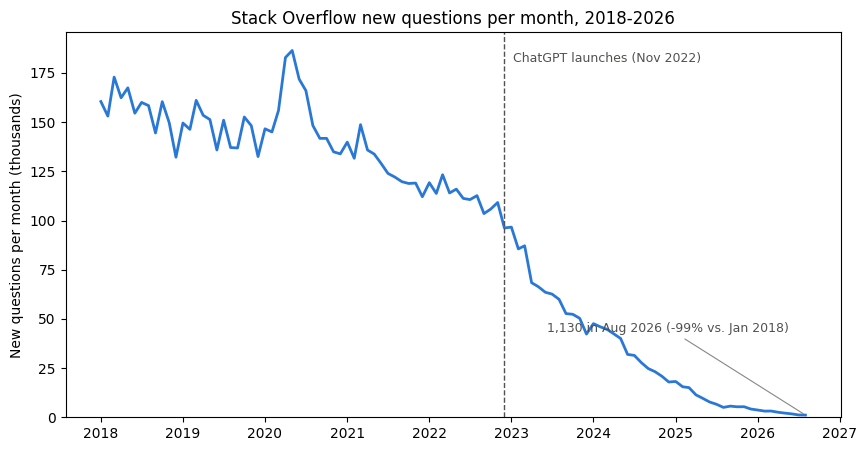

In [17]:
def plot_stackoverflow_questions():
    CHATGPT = pd.Timestamp("2022-11-30")
    first, last = so.iloc[0], so.iloc[-1]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(so["month"], so["questions"] / 1e3, color="#2a78d6", lw=2)

    ax.axvline(CHATGPT, color="#52514e", lw=1, ls="--")
    ax.annotate("ChatGPT launches (Nov 2022)", (CHATGPT, 0.95), xycoords=("data", "axes fraction"),
                xytext=(6, 0), textcoords="offset points", va="top", fontsize=9, color="#52514e")

    pct = 100 * (last["questions"] / first["questions"] - 1)
    ax.annotate(f"{last['questions']:,} in {last['month']:%b %Y} ({pct:.0f}% vs. {first['month']:%b %Y})",
                (last["month"], last["questions"] / 1e3), xytext=(-12, 60), textcoords="offset points",
                ha="right", fontsize=9, color="#52514e",
                arrowprops=dict(arrowstyle="-", color="#898781", lw=0.8))

    ax.set_ylim(0, None)
    ax.set_ylabel("New questions per month (thousands)")
    ax.set_title("Stack Overflow new questions per month, 2018-2026")
    fig.savefig(FIG / "stackoverflow_questions.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_stackoverflow_questions()

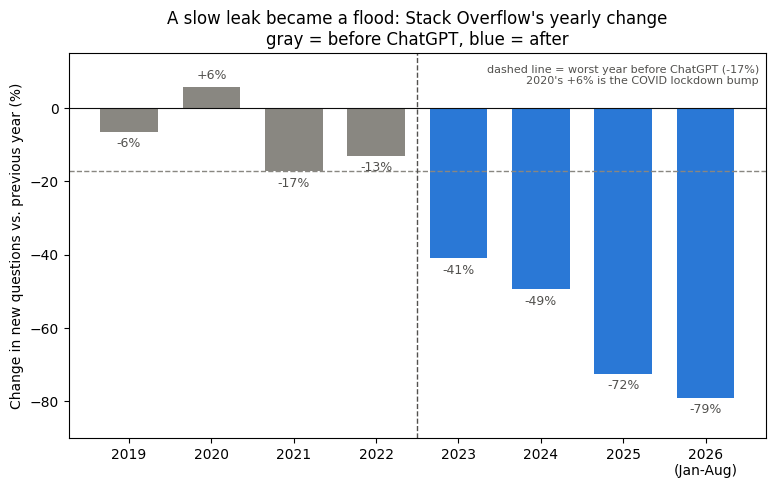

In [21]:
def plot_stackoverflow_year_change(so):
    full = so[so["month"].dt.year <= 2025].groupby(so["month"].dt.year)["questions"].sum()
    yoy = (100 * (full / full.shift() - 1)).dropna()
    ytd_2026 = so[so["month"] >= "2026-01-01"]["questions"].sum()
    ytd_2025 = so[(so["month"] >= "2025-01-01") & (so["month"] <= "2025-08-01")]["questions"].sum()
    yoy.loc[2026] = 100 * (ytd_2026 / ytd_2025 - 1)

    worst = yoy[yoy.index <= 2022].min()
    labels = [str(y) if y < 2026 else "2026\n(Jan-Aug)" for y in yoy.index]
    colors = ["#898781" if y <= 2022 else "#2a78d6" for y in yoy.index]

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(yoy))
    ax.bar(x, yoy, color=colors, width=0.7)
    for xi, v in zip(x, yoy):
        ax.text(xi, v + (1.5 if v > 0 else -1.5), f"{v:+.0f}%", ha="center",
                va="bottom" if v > 0 else "top", fontsize=9, color="#52514e")

    ax.axhline(0, color="#0b0b0b", lw=0.8)
    ax.axhline(worst, color="#898781", lw=1, ls="--")
    ax.axvline(3.5, color="#52514e", lw=1, ls="--")

    ax.text(0.99, 0.97, f"dashed line = worst year before ChatGPT ({worst:.0f}%)\n"
                        "2020's +6% is the COVID lockdown bump",
            transform=ax.transAxes, ha="right", va="top", fontsize=8, color="#52514e")

    ax.set_xticks(x, labels)
    ax.set_ylim(-90, 15)
    ax.set_ylabel("Change in new questions vs. previous year (%)")
    ax.set_title("A slow leak became a flood: Stack Overflow's yearly change\n"
                 "gray = before ChatGPT, blue = after")
    fig.savefig(FIG / "stackoverflow_year_change.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_stackoverflow_year_change(so=so)

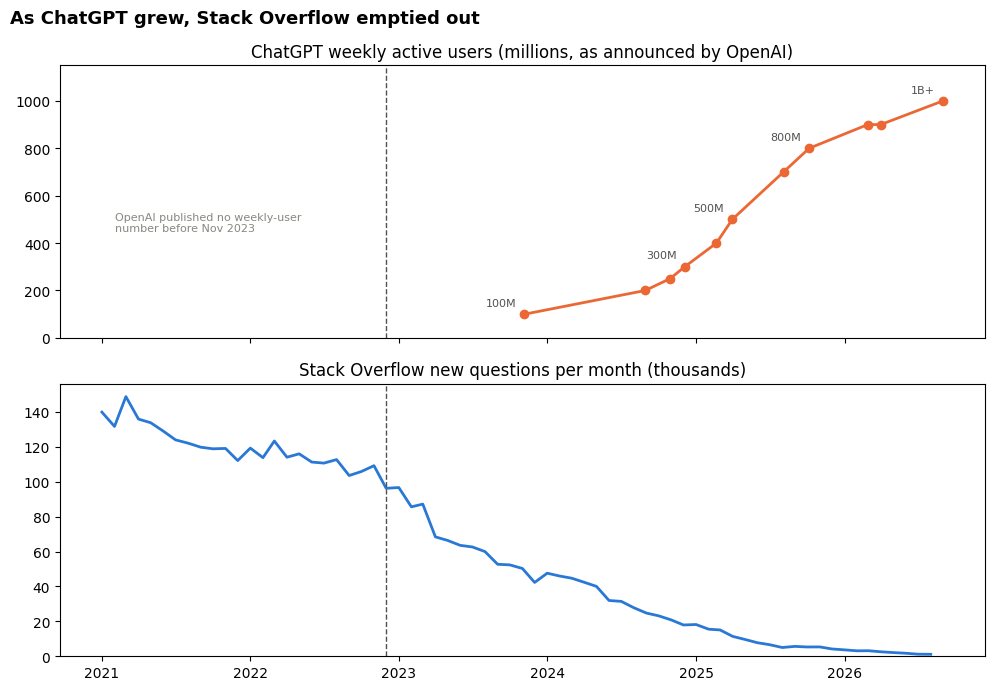

      date  weekly_users_millions  questions
2023-11-06                    100      50285
2024-08-29                    200      27788
2024-10-29                    250      23167
2024-12-04                    300      17927
2025-02-20                    400      15506
2025-03-31                    500      15078
2025-08-04                    700       5023
2025-10-06                    800       5331
2026-02-27                    900       3128
2026-03-31                    900       3179
2026-08-31                   1000       1130


In [18]:
def plot_chatgpt_vs_stackoverflow(so, wau):
    CHATGPT = pd.Timestamp("2022-11-30")
    recent = so[so["month"] >= "2021-01-01"]

    fig, (top, bottom) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    top.plot(wau["date"], wau["weekly_users_millions"], color="#eb6834", marker="o", lw=2)
    for _, row in wau.iloc[[0, 3, 5, 7, -1]].iterrows():
        n = row["weekly_users_millions"]
        top.annotate("1B+" if n >= 1000 else f"{n}M", (row["date"], n), xytext=(-6, 6),
                     textcoords="offset points", ha="right", fontsize=8, color="#52514e")
    top.text(pd.Timestamp("2021-02-01"), 450, "OpenAI published no weekly-user\nnumber before Nov 2023",
             fontsize=8, color="#898781")
    top.set_ylim(0, 1150)
    top.set_title("ChatGPT weekly active users (millions, as announced by OpenAI)")

    bottom.plot(recent["month"], recent["questions"] / 1e3, color="#2a78d6", lw=2)
    bottom.set_ylim(0, None)
    bottom.set_title("Stack Overflow new questions per month (thousands)")

    for ax in (top, bottom):
        ax.axvline(CHATGPT, color="#52514e", lw=1, ls="--")
    fig.suptitle("As ChatGPT grew, Stack Overflow emptied out", x=0.01, ha="left", fontsize=13, weight="bold")
    fig.tight_layout()
    fig.savefig(FIG / "chatgpt_vs_stackoverflow.png", dpi=150, bbox_inches="tight")
    plt.show()

    matched = wau.merge(so, on="month")[["date", "weekly_users_millions", "questions"]]
    print(matched.to_string(index=False))

plot_chatgpt_vs_stackoverflow(so=so, wau=wau)

year
2023    44.4
2024    61.8
2025    78.5


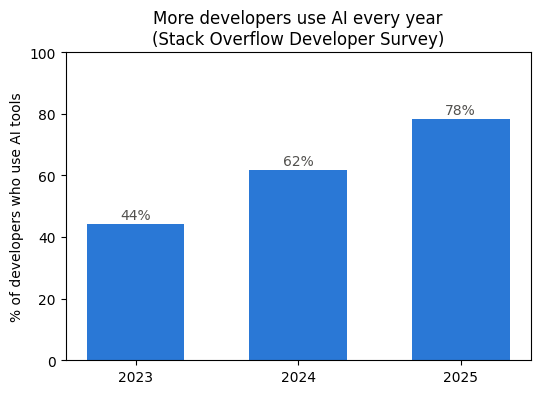

In [19]:
def plot_ai_adoption(sv):
    share = sv.dropna(subset=["uses_ai"]).groupby("year")["uses_ai"].apply(lambda s: (s == "uses AI").mean() * 100)
    print(share.round(1).to_string())

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(share.index.astype(str), share, color="#2a78d6", width=0.6)
    for x, v in enumerate(share):
        ax.text(x, v + 1.5, f"{v:.0f}%", ha="center", fontsize=10, color="#52514e")
    ax.set_ylim(0, 100)
    ax.set_ylabel("% of developers who use AI tools")
    ax.set_title("More developers use AI every year\n(Stack Overflow Developer Survey)")
    fig.savefig(FIG / "stackoverflow_survey_ai_adoption.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_ai_adoption(sv=sv)

uses_ai  does not  uses AI
year                      
2023         35.8     40.7
2024         36.3     37.4
2025         31.3     23.2


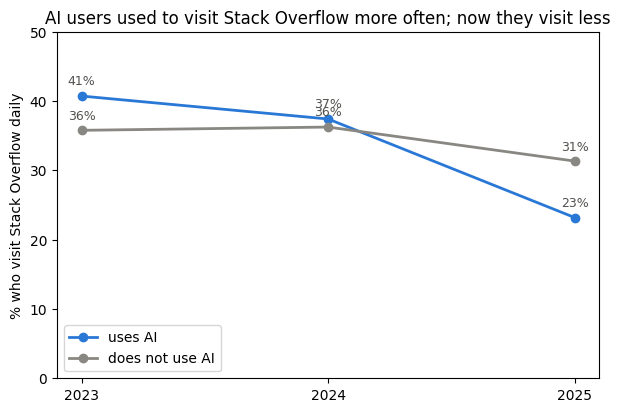

In [20]:
def plot_daily_visits_by_ai_use(sv):
    answered = sv.dropna(subset=["uses_ai", "visits_so_daily"])
    answered = answered[answered["uses_ai"] != "plans to"]
    daily = answered.groupby(["year", "uses_ai"])["visits_so_daily"].apply(lambda s: s.astype(bool).mean() * 100).unstack()
    print(daily.round(1).to_string())

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for group, color, label in [("uses AI", "#2a78d6", "uses AI"), ("does not", "#898781", "does not use AI")]:
        ax.plot(daily.index, daily[group], color=color, marker="o", lw=2, label=label)
        for year, v in daily[group].items():
            ax.annotate(f"{v:.0f}%", (year, v), xytext=(0, 8), textcoords="offset points", ha="center",
                        fontsize=9, color="#52514e")
    ax.set_xticks(daily.index)
    ax.set_ylim(0, 50)
    ax.set_ylabel("% who visit Stack Overflow daily")
    ax.set_title("AI users used to visit Stack Overflow more often; now they visit less")
    ax.legend(loc="lower left")
    fig.savefig(FIG / "stackoverflow_daily_visits_by_ai_use.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_daily_visits_by_ai_use(sv=sv)

trend before ChatGPT: -7.7% per year
       questions   expected  gap_pct
month                               
2023      787779  1284226.6    -38.7
2024      398448  1185246.7    -66.4
2025      109770  1093895.4    -90.0
2026       18719   690661.4    -97.3


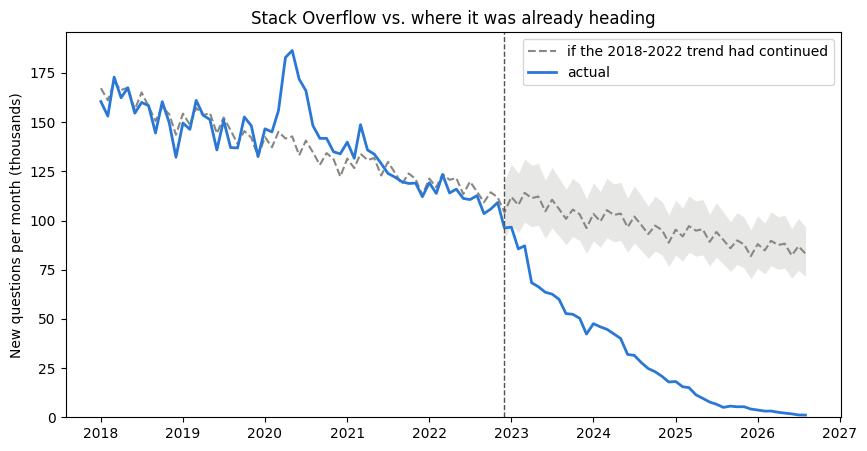

In [22]:
import statsmodels.formula.api as smf

def plot_trend_counterfactual(so):
    CHATGPT = pd.Timestamp("2022-11-30")
    df = so.copy()
    df["log_questions"] = np.log(df["questions"])
    df["t"] = np.arange(len(df)) / 12                                           # years since Jan 2018
    df["month_of_year"] = df["month"].dt.month                                  # seasonality
    df["covid"] = df["month"].between("2020-03-01", "2020-06-01").astype(int)   # lockdown spike

    before = df[df["month"] < "2022-12-01"]
    model = smf.ols("log_questions ~ t + covid + C(month_of_year)", data=before).fit()
    pred = model.get_prediction(df.assign(covid=0)).summary_frame(alpha=0.05)
    df["expected"] = np.exp(pred["mean"])
    df["low"], df["high"] = np.exp(pred["obs_ci_lower"]), np.exp(pred["obs_ci_upper"])

    after = df[df["month"] >= "2022-12-01"]
    yearly = df[df["month"].dt.year >= 2023].groupby(df["month"].dt.year)[["questions", "expected"]].sum()
    yearly["gap_pct"] = 100 * (yearly["questions"] / yearly["expected"] - 1)
    print(f"trend before ChatGPT: {100 * (np.exp(model.params['t']) - 1):.1f}% per year")
    print(yearly.round(1).to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(after["month"], after["low"] / 1e3, after["high"] / 1e3, color="#898781", alpha=0.2, lw=0)
    ax.plot(df["month"], df["expected"] / 1e3, color="#898781", ls="--", lw=1.5,
            label="if the 2018-2022 trend had continued")
    ax.plot(df["month"], df["questions"] / 1e3, color="#2a78d6", lw=2, label="actual")
    ax.axvline(CHATGPT, color="#52514e", lw=1, ls="--")
    ax.set_ylim(0, None)
    ax.set_ylabel("New questions per month (thousands)")
    ax.set_title("Stack Overflow vs. where it was already heading")
    ax.legend(loc="upper right")
    fig.savefig(FIG / "trend_counterfactual.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_trend_counterfactual(so=so)